# 08_crash_analysis

## Project Title: Traffic Accident Risk Prediction (TARP)

**Unit:** SIT782  
**Prepared by:** Khalid  
**Project Team:** Suba (225094537), Burhan (224802775), Khalid (224696667)  
**Task:** Perform Exploratory Data Analysis (EDA) to identify crash patterns and high-risk locations (Week 3 of 8)

This notebook performs exploratory analysis on the cleaned crash dataset with a focus on three required tasks:

1. Accident counts by hour  
2. Accident counts by weekday  
3. Identification of high-risk locations  

The goal is to uncover temporal and spatial crash patterns that may support later modeling and decision-making.

## 1. Import libraries and load dataset

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

import os
os.chdir(r"D:\Git\SIT782\TARP01\MOP-Code\Playground\KhalidT12026\Traffic_Accident_Prediction\data\processed")

df = pd.read_csv('cleaned_crash_data.csv')

df.head()

,ACCIDENT_NO,ACCIDENT_DATE,ACCIDENT_TIME,ACCIDENT_TYPE,DAY_OF_WEEK,DCA_CODE,DCA_CODE_DESCRIPTION,LIGHT_CONDITION,POLICE_ATTEND,ROAD_GEOMETRY,...,PT_VEHICLE,DEG_URBAN_NAME,SRNS,RMA,DIVIDED,STAT_DIV_NAME,hour,day_name,month,year
0,T20230013207,2023-06-06,1900-01-01 22:14:00,Collision with vehicle,Tuesday,140,U TURN,Dark Street lights on,Yes,Not at intersection,...,0.0,MELB_URBAN,NaN,Arterial Other,Undivided,METRO,22.0,Tuesday,6,2023
1,T20240014902,2024-04-19,1900-01-01 02:10:00,Collision with vehicle,Friday,140,U TURN,Dark Street lights on,Yes,Not at intersection,...,0.0,MELB_URBAN,NaN,Local Road,Undivided,METRO,2.0,Friday,4,2024
2,T20160009452,2016-04-30,1900-01-01 23:50:00,Collision with vehicle,Saturday,120,HEAD ON (NOT OVERTAKING),Dark No street lights,Yes,Not at intersection,...,0.0,RURAL_VICTORIA,C,Arterial Other,Undivided,COUNTRY,23.0,Saturday,4,2016
3,T20230001223,2023-01-17,1900-01-01 15:56:00,Collision with vehicle,Tuesday,113,RIGHT NEAR (INTERSECTIONS ONLY),Day,Yes,Private property,...,0.0,RURAL_VICTORIA,A,Arterial Highway,Undivided,COUNTRY,15.0,Tuesday,1,2023
4,T20220001324,2022-01-21,1900-01-01 22:45:00,Fall from or in moving vehicle,Friday,190,FELL IN/FROM VEHICLE,Dark Street lights on,Yes,Cross intersection,...,0.0,TOWNS,NaN,Local Road,Undivided,COUNTRY,22.0,Friday,1,2022


## 2. Inspect columns and prepare date/time fields

The cleaned dataset already contains useful time-related columns, but this notebook also derives analysis-ready features directly from the original accident date and accident time fields to ensure consistency.

- `ACCIDENT_DATE` is converted to datetime
- `ACCIDENT_TIME` is converted to time-aware format
- `hour` is extracted for hourly crash analysis
- `weekday_name` is extracted for weekday crash analysis

In [5]:
# Convert date column
df['ACCIDENT_DATE'] = pd.to_datetime(df['ACCIDENT_DATE'], errors='coerce')

# Convert time column
df['ACCIDENT_TIME'] = pd.to_datetime(df['ACCIDENT_TIME'], errors='coerce')

# Create derived features
df['hour'] = df['ACCIDENT_TIME'].dt.hour
df['weekday_name'] = df['ACCIDENT_DATE'].dt.day_name()

# Quick check
df[['ACCIDENT_DATE', 'ACCIDENT_TIME', 'hour', 'weekday_name']].head()

,ACCIDENT_DATE,ACCIDENT_TIME,hour,weekday_name
0,2023-06-06,1900-01-01 22:14:00,22,Tuesday
1,2024-04-19,1900-01-01 02:10:00,2,Friday
2,2016-04-30,1900-01-01 23:50:00,23,Saturday
3,2023-01-17,1900-01-01 15:56:00,15,Tuesday
4,2022-01-21,1900-01-01 22:45:00,22,Friday


## 3. Accident counts by hour

This analysis shows how crashes are distributed across the 24 hours of the day.  
It helps identify peak crash times, which may reflect traffic congestion, commuting periods, reduced visibility, or driver fatigue.

In [6]:
hourly_counts = df['hour'].value_counts().sort_index()

print(hourly_counts)

hour
0      2497
1      2090
2      1614
3      1511
4      1499
5      2699
6      6056
7      8405
8     12263
9     10132
10    10035
11    11127
12    11959
13    11589
14    12386
15    15904
16    15779
17    15809
18    12976
19     8243
20     5989
21     5571
22     4635
23     3584
Name: count, dtype: int64


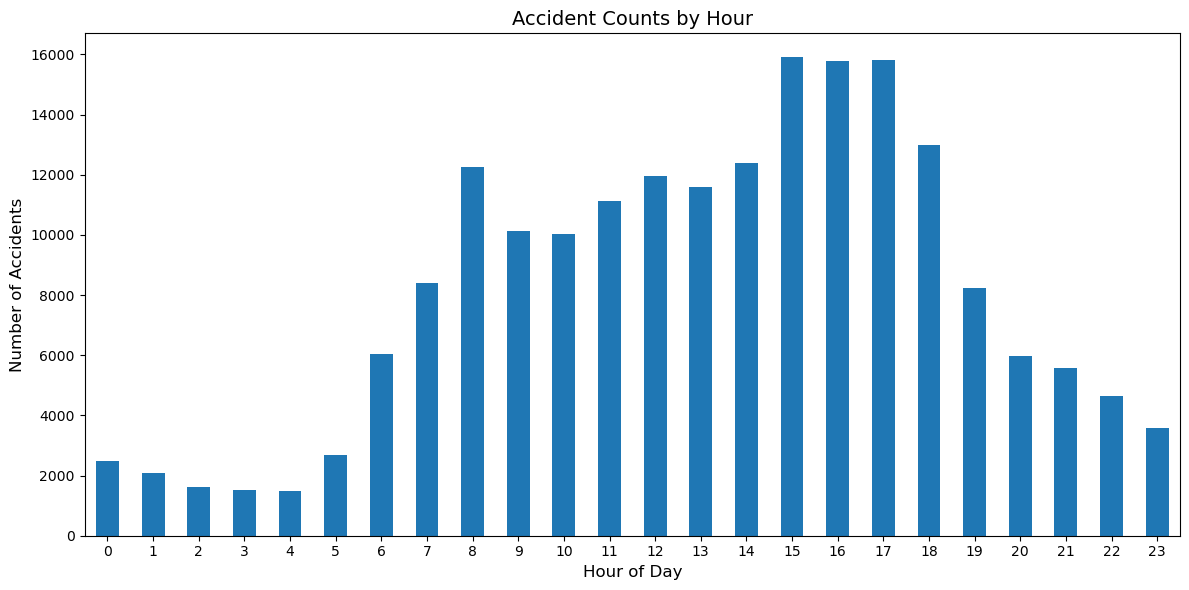

In [7]:
plt.figure(figsize=(12, 6))
hourly_counts.plot(kind='bar')
plt.title('Accident Counts by Hour', fontsize=14)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Interpretation: Accident counts by hour

The analysis of accident frequency across the 24-hour period reveals strong temporal patterns associated with daily traffic behaviour.

#### Key Findings:

- Accident counts are **lowest during late night and early morning hours (1 AM – 5 AM)**, with the minimum around **3–4 AM**, indicating reduced traffic volume.

- A **sharp increase begins from 6 AM onwards**, corresponding to morning commuting activity.

- A clear **morning peak occurs between 7 AM and 9 AM**, aligning with work and school travel.

- Accident frequency remains **consistently high during midday (10 AM – 2 PM)**, suggesting sustained traffic flow.

- The **highest number of accidents occurs in the late afternoon (3 PM – 6 PM)**, peaking around **3–5 PM** due to:
  - Increased traffic congestion  
  - Higher traffic density  
  - Driver fatigue after work  

- After 6 PM, accident counts **gradually decline**, though remain moderate until around 8 PM before decreasing further.

#### Overall Insight:

- Traffic congestion and commuting patterns are the **primary drivers of accident frequency**, with peak crash risk during **morning and evening rush hours**, particularly in the late afternoon.

- The **stronger afternoon peak compared to the morning** suggests additional contributing factors such as:
  - Driver fatigue  
  - Trip chaining (multiple stops)  
  - Higher variability in traffic conditions  

## 4. Accident counts by weekday

This analysis examines whether crashes occur more often on certain days of the week.  
Understanding weekday patterns can reveal the effect of work commuting, weekend travel, or changing traffic conditions across the week.

In [8]:
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_counts = df['weekday_name'].value_counts().reindex(weekday_order)

print(weekday_counts)

weekday_name
Monday       26468
Tuesday      28159
Wednesday    29109
Thursday     29440
Friday       30622
Saturday     27087
Sunday       23467
Name: count, dtype: int64


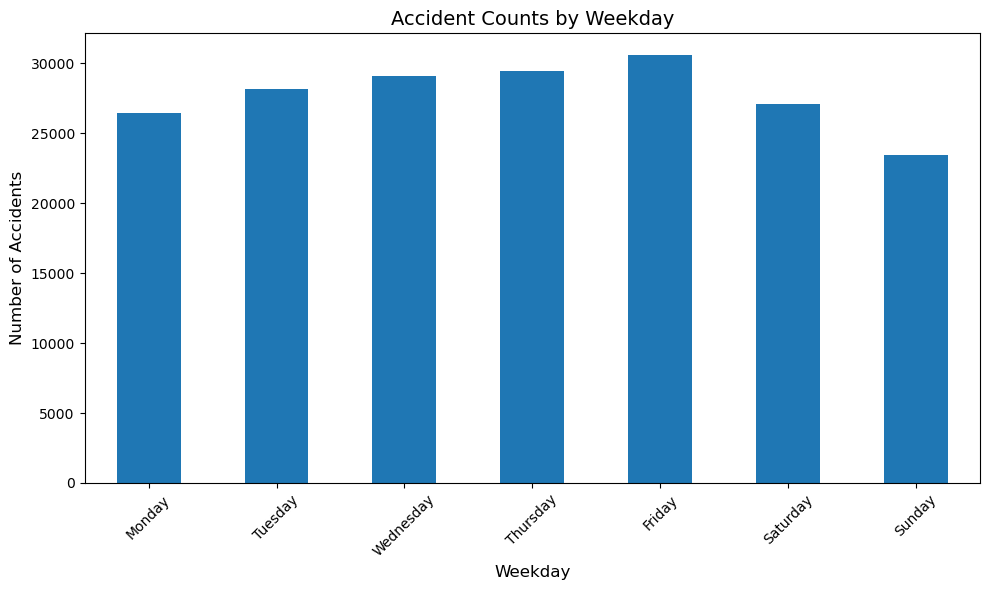

In [9]:
plt.figure(figsize=(10, 6))
weekday_counts.plot(kind='bar')
plt.title('Accident Counts by Weekday', fontsize=14)
plt.xlabel('Weekday', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretation: Accident counts by weekday

The analysis of accident frequency across the days of the week reveals clear patterns associated with work routines, travel behaviour, and weekend activity.

#### Key Findings:

- Accident counts show a **gradual increase from Monday (26,468) to Friday (30,622)**, indicating rising traffic activity as the workweek progresses.

- **Friday records the highest number of accidents**, suggesting increased travel demand due to:
  - End-of-week commuting  
  - Social and leisure activities  
  - Higher traffic congestion  

- **Midweek days (Wednesday and Thursday)** also exhibit relatively high accident counts, reflecting consistently heavy weekday traffic.

- Accident counts **decline over the weekend**, with:
  - **Saturday (27,087)** showing a moderate drop  
  - **Sunday (23,467)** recording the lowest accident count overall  

- The **lowest accident frequency on Sunday** indicates reduced commuting traffic and overall lower road usage.

#### Overall Insight:

- Accident frequency is strongly influenced by **work-related commuting patterns**, with peak risk occurring towards the **end of the workweek**.

- The decline during weekends suggests that **traffic volume is a key contributing factor**, although weekend accidents may still occur due to different causes such as recreational travel.

#### Additional Observation:

- The steady increase from Monday to Friday suggests **cumulative traffic pressure and behavioural factors**, such as fatigue or increased mobility, contributing to higher crash risk later in the week.

## 5. Identify high-risk locations

To identify accident hotspots, this notebook uses location-based counts.  
Two views are provided:

1. **High-risk local government areas (LGA_NAME)** for broader regional hotspots  
2. **High-risk roads (ROAD_NAME)** for more specific crash-prone corridors  

This helps pinpoint where crashes are concentrated most heavily.

In [10]:
# Top 10 high-risk LGAs
top_lga = df['LGA_NAME'].value_counts().head(10)
print(top_lga)

LGA_NAME
MELBOURNE       10127
CASEY            8775
GEELONG          7636
HUME             7049
DANDENONG        6702
BRIMBANK         6009
MONASH           5816
WHITTLESEA       5764
YARRA RANGES     5289
MORELAND         5286
Name: count, dtype: int64


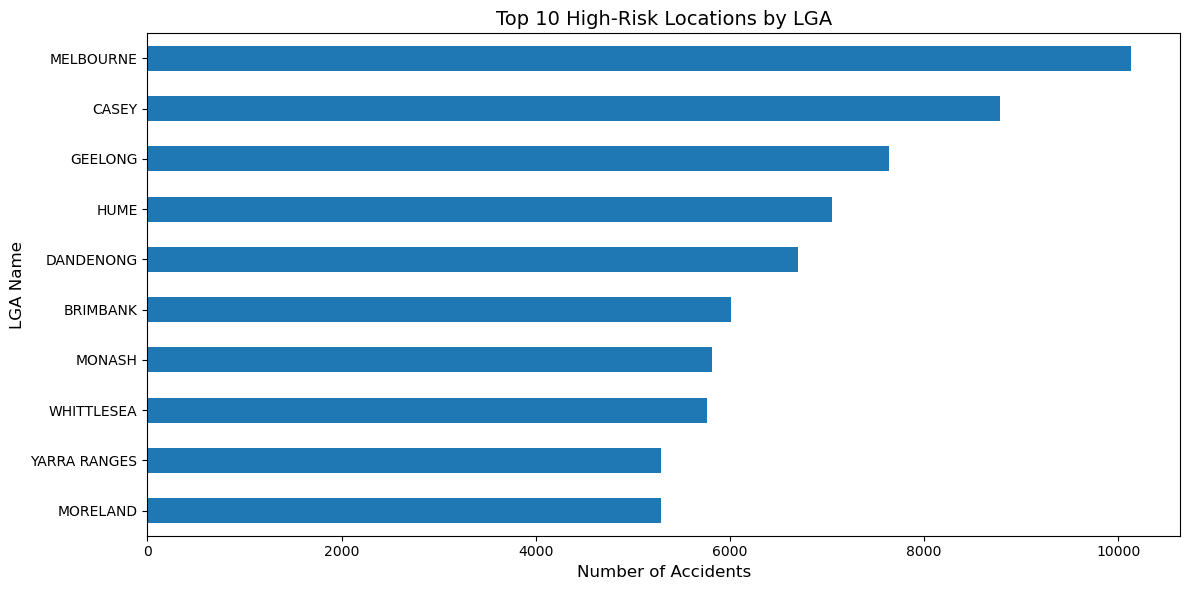

In [11]:
plt.figure(figsize=(12, 6))
top_lga.sort_values().plot(kind='barh')
plt.title('Top 10 High-Risk Locations by LGA', fontsize=14)
plt.xlabel('Number of Accidents', fontsize=12)
plt.ylabel('LGA Name', fontsize=12)
plt.tight_layout()
plt.show()

In [12]:
# Top 10 high-risk roads
top_roads = df['ROAD_NAME'].value_counts().head(10)
print(top_roads)

ROAD_NAME
PRINCES            4974
HIGH               2741
NEPEAN             1898
MONASH             1794
SOUTH GIPPSLAND    1701
SYDNEY             1494
DANDENONG          1425
SPRINGVALE         1398
WESTERN            1383
HUME               1323
Name: count, dtype: int64


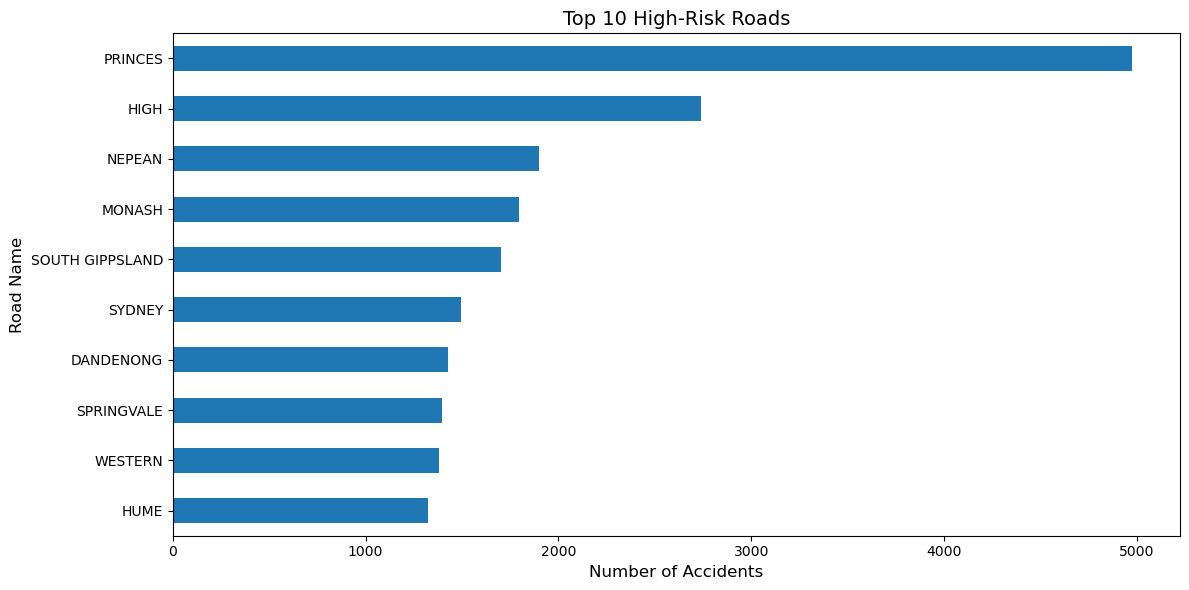

In [13]:
plt.figure(figsize=(12, 6))
top_roads.sort_values().plot(kind='barh')
plt.title('Top 10 High-Risk Roads', fontsize=14)
plt.xlabel('Number of Accidents', fontsize=12)
plt.ylabel('Road Name', fontsize=12)
plt.tight_layout()
plt.show()

### Optional: Most common exact crash coordinates

If latitude and longitude are available and reliable, repeated coordinate pairs can be used to identify highly concentrated crash points.  
This view is more granular, although nearby crashes may still appear as separate coordinate pairs.

In [14]:
high_risk_coordinates = (
    df.dropna(subset=['LATITUDE', 'LONGITUDE'])
      .groupby(['LATITUDE', 'LONGITUDE'])
      .size()
      .reset_index(name='accident_count')
      .sort_values('accident_count', ascending=False)
      .head(10)
)

high_risk_coordinates

,LATITUDE,LONGITUDE,accident_count
78329,-37.792260,144.96838,74
24868,-38.059930,145.33846,55
38653,-37.933174,145.15694,54
19071,-38.113033,145.28279,49
71615,-37.810318,144.96136,47
73651,-37.805020,144.69594,46
35334,-37.961178,145.36115,44
78095,-37.793045,144.97572,44
79156,-37.789406,144.94217,44
99091,-37.703170,145.08983,44


### Interpretation: High-risk locations

The spatial analysis of crash data identifies key high-risk locations across Local Government Areas (LGAs), major roads, and specific geographic coordinates. These insights highlight areas with consistently high accident frequency and potential infrastructure or traffic-related risks.

#### Key Findings (LGA Level):

- **Melbourne records the highest number of accidents (10,127)**, significantly higher than other LGAs, indicating a major concentration of crash incidents in the central metropolitan area.

- Other high-risk LGAs include:
  - **Casey (8,775)**
  - **Geelong (7,636)**
  - **Hume (7,049)**
  - **Dandenong (6,702)**  

- These LGAs are characterised by:
  - High population density  
  - Major transport corridors  
  - Significant commuter traffic  

- Outer suburban regions such as **Whittlesea, Yarra Ranges, and Moreland** also show notable accident counts, suggesting expanding traffic pressure beyond central areas.

#### Key Findings (Road Level):

- **Princes Highway is the most high-risk road (4,974 accidents)**, substantially exceeding all other roads.

- Other major high-risk roads include:
  - **High Street (2,741)**
  - **Nepean Highway (1,898)**
  - **Monash Freeway (1,794)**
  - **South Gippsland Highway (1,701)**  

- These roads are typically:
  - High-capacity arterial roads or highways  
  - Major commuter routes  
  - Areas with high vehicle speeds and traffic volumes  

- The presence of multiple highways in the top list indicates that **high-speed corridors significantly contribute to accident risk**.

#### Key Findings (Exact Coordinates):

- Several geographic points show repeated accident occurrences, with the highest location recording **74 accidents at a single coordinate**.

- Other hotspot coordinates report between **44 and 55 accidents**, indicating localized high-risk zones.

- These hotspots likely correspond to:
  - Busy intersections  
  - Traffic signal zones  
  - Complex road layouts or merging points  

#### Overall Insight:

- Accident risk is highly concentrated in **urban centres and along major transport corridors**, where traffic density and interaction complexity are greatest.

- The combination of:
  - High traffic volume  
  - Road design complexity  
  - Speed variations contributes significantly to increased crash frequency.

#### Additional Observation:

- While LGAs provide a broad view of high-risk regions, **road-level and coordinate-level analysis offer more precise insights**, which are critical for targeted road safety interventions such as:
  - Infrastructure improvements  
  - Traffic signal optimization  
  - Speed regulation enforcement  

## 6. Discussion of Findings

#### Accident counts by hour:
The hourly distribution of crashes reveals clear temporal patterns, with accident frequency peaking during **morning (7–9 AM)** and **late afternoon to early evening (3–6 PM)** periods. The highest concentration of accidents occurs in the late afternoon, suggesting the combined impact of **traffic congestion, increased traffic density, and driver fatigue after work hours**. In contrast, accident counts are significantly lower during late night and early morning hours, reflecting reduced traffic volume.

#### Accident counts by weekday:
The weekday analysis indicates that accident frequency increases progressively from **Monday to Friday**, with **Friday recording the highest number of crashes**. This trend highlights the influence of **work-related commuting patterns and increased end-of-week travel activity**. A noticeable decline in accidents over the weekend, particularly on Sunday, suggests reduced traffic demand and lower road usage compared to weekdays.

#### High-risk locations:
The spatial analysis identifies several high-risk areas, with **Melbourne, Casey, and Geelong** emerging as the most affected LGAs. At the road level, major arterial routes such as **Princes Highway and Monash Freeway** exhibit the highest accident counts, indicating the role of **high traffic volume and speed** in crash occurrence. Additionally, specific geographic hotspots with repeated accident occurrences point to **critical locations such as intersections, merging zones, and complex road layouts**, which may require targeted safety interventions.

## 7. Summary of EDA findings

This exploratory analysis examined both the **temporal** and **spatial** distribution of road crashes, revealing clear patterns in when and where accidents are most likely to occur.

#### Key Insights:

- **Hourly patterns** show that accidents peak during **morning (7–9 AM)** and **evening (3–6 PM) commuting hours**, with the highest frequency observed in the late afternoon. This indicates that **traffic congestion and driver fatigue** are major contributing factors.

- **Weekday analysis** reveals a steady increase in accidents from **Monday to Friday**, with **Friday recording the highest number of crashes**. This suggests that end-of-week traffic demand and increased travel activity elevate crash risk.

- **Spatial analysis** highlights that accidents are highly concentrated in:
  - **Urban LGAs such as Melbourne, Casey, and Geelong**
  - **Major arterial roads and highways such as Princes Highway and Monash Freeway**
  - **Specific geographic hotspots**, likely representing busy intersections or complex traffic zones  

#### Overall Conclusion:

The results clearly demonstrate that accident frequency is strongly influenced by **traffic volume, commuting behaviour, and road infrastructure characteristics**. High-risk periods and locations align with areas of increased traffic density and complexity.

These findings provide a strong foundation for the next stages of the project, particularly for:
- **Predictive modeling of accident risk**
- **Targeted road safety interventions**
- **Data-driven traffic management strategies**